

MNIST Deep Learning (PyTorch)



In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns



In [11]:
# Transform images to tensor
transform = transforms.ToTensor()

# Load MNIST training dataset
train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

# Load MNIST test dataset
test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    transform=transform
)

# Data loaders
train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset,
    batch_size=64,
    shuffle=False
)


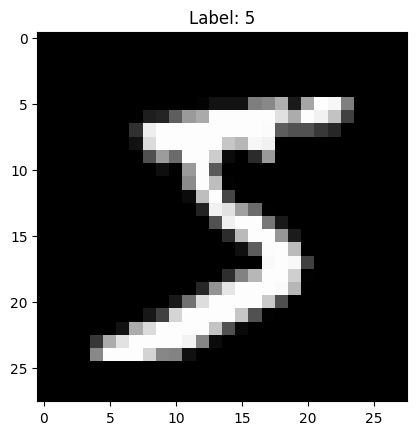

In [12]:
# Visualize one sample
image, label = train_dataset[0]
plt.imshow(image.squeeze(), cmap='gray')
plt.title(f"Label: {label}")
plt.show()


In [13]:
# Define a simple Neural Network for MNIST
class MNISTModel(nn.Module):
    def __init__(self):
        super(MNISTModel, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),         # Flatten 28x28 image to 784
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)    # Output 10 classes
        )

    def forward(self, x):
        return self.model(x)

model = MNISTModel()

In [14]:

# Define the loss function (Cross-Entropy for classification)
criterion = nn.CrossEntropyLoss()  # <-- Loss function

# Define the optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [15]:
epochs = 15
train_losses = []
train_accuracies = []

for epoch in range(epochs):
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        outputs = model(images)

        # Compute the loss
        loss = criterion(outputs, labels)  # <-- Loss calculated here

        # Backpropagation
        optimizer.zero_grad()   # Clear previous gradients
        loss.backward()         # <-- Backpropagation happens here
        optimizer.step()        # Update weights

        total_loss += loss.item()

        # Calculate training accuracy
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    avg_loss = total_loss / len(train_loader)

    train_losses.append(avg_loss)
    train_accuracies.append(accuracy)

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%")


Epoch [1/15] Loss: 0.3487, Accuracy: 89.98%
Epoch [2/15] Loss: 0.1449, Accuracy: 95.65%
Epoch [3/15] Loss: 0.0991, Accuracy: 97.08%
Epoch [4/15] Loss: 0.0724, Accuracy: 97.83%
Epoch [5/15] Loss: 0.0581, Accuracy: 98.15%
Epoch [6/15] Loss: 0.0465, Accuracy: 98.56%
Epoch [7/15] Loss: 0.0359, Accuracy: 98.88%
Epoch [8/15] Loss: 0.0305, Accuracy: 98.99%
Epoch [9/15] Loss: 0.0261, Accuracy: 99.15%
Epoch [10/15] Loss: 0.0213, Accuracy: 99.29%
Epoch [11/15] Loss: 0.0192, Accuracy: 99.35%
Epoch [12/15] Loss: 0.0158, Accuracy: 99.50%
Epoch [13/15] Loss: 0.0145, Accuracy: 99.49%
Epoch [14/15] Loss: 0.0115, Accuracy: 99.64%
Epoch [15/15] Loss: 0.0128, Accuracy: 99.59%


In [16]:
# Test the model
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 97.67%


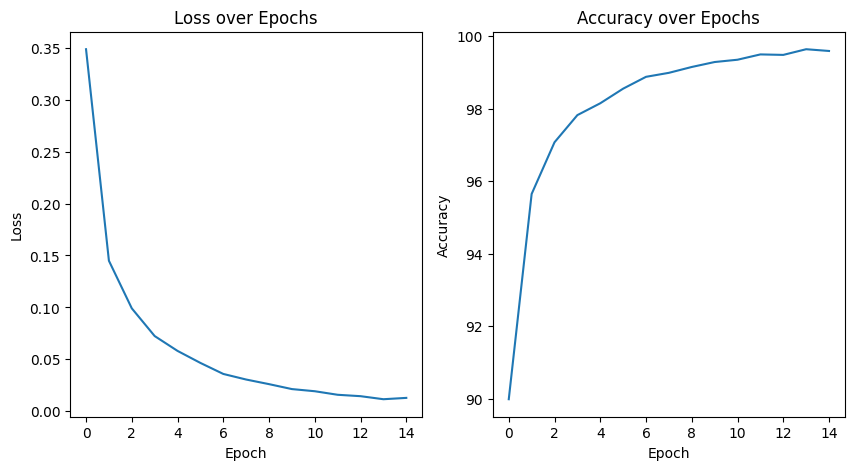

In [17]:
# Plot loss and accuracy curves
plt.figure(figsize=(10,5))

# Loss
plt.subplot(1,2,1)
plt.plot(train_losses)
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Accuracy
plt.subplot(1,2,2)
plt.plot(train_accuracies)
plt.title("Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.show()

Test Accuracy: 97.67%
Classification Report:

              precision    recall  f1-score   support

           0     0.9888    0.9878    0.9883       980
           1     0.9876    0.9841    0.9859      1135
           2     0.9833    0.9700    0.9766      1032
           3     0.9850    0.9752    0.9801      1010
           4     0.9865    0.9664    0.9763       982
           5     0.9840    0.9664    0.9751       892
           6     0.9702    0.9864    0.9783       958
           7     0.9813    0.9698    0.9755      1028
           8     0.9270    0.9908    0.9578       974
           9     0.9751    0.9693    0.9722      1009

    accuracy                         0.9767     10000
   macro avg     0.9769    0.9766    0.9766     10000
weighted avg     0.9771    0.9767    0.9768     10000



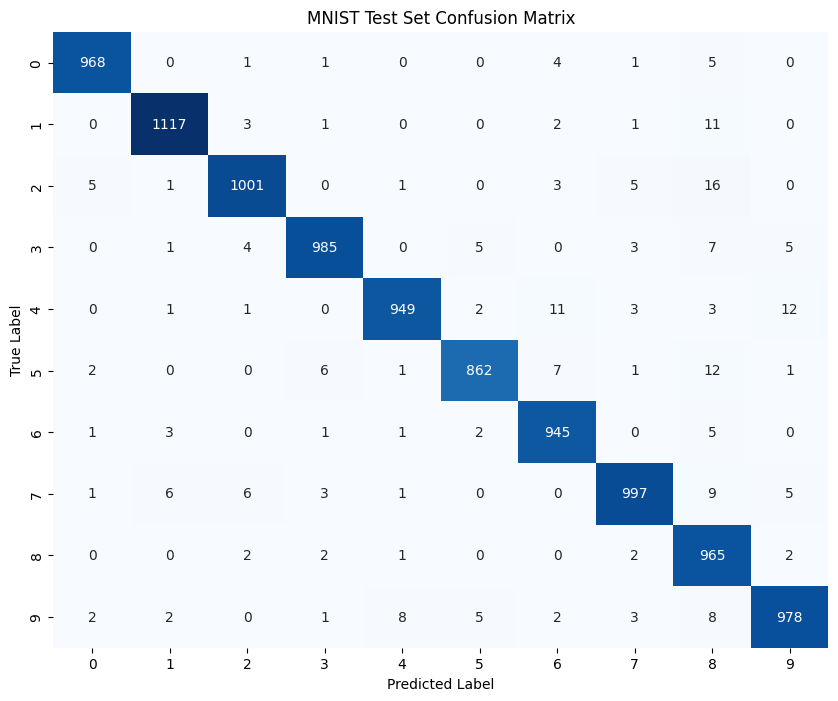

In [19]:

# Confusion matrix and classification report
model.eval()
all_labels = []
all_predicted = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_labels.extend(labels.numpy())
        all_predicted.extend(predicted.numpy())

# Accuracy
correct = sum([1 for a, b in zip(all_labels, all_predicted) if a == b])
total = len(all_labels)
test_accuracy = 100 * correct / total
print(f"Test Accuracy: {test_accuracy:.2f}%")
ccuracy: {test_accuracy:.2f}%")


# Detailed classification report
report = classification_report(all_labels, all_predicted, digits=4)
print("Classification Report:\n")
print(report)

# Confusion matrix heatmap
cm = confusion_matrix(all_labels, all_predicted)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("MNIST Test Set Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()